In [90]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [91]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
data = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_2168\277842057.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("C:\Datasets\phishing+websites\phishing_dataset.csv")


In [93]:
data.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [94]:
data.shape

(11055, 32)

In [95]:
data["Result"].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           11055 non-null  int64
 1   having_IP_Address            11055 non-null  int64
 2   URL_Length                   11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [97]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [98]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [99]:
X = data.drop(["id","Result"], axis=1)
y = data["Result"]

In [100]:
y = y.replace(-1, 0)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [102]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss")

model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [104]:
import joblib

joblib.dump(model, 'safe_surfer_xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [105]:
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy: 97.20%
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       980
           1       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

Confusion Matrix:
[[ 940   40]
 [  22 1209]]


In [106]:
# Save the model to disk
joblib.dump(model, 'safe_surfer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved successfully as safe_surfer_model.pkl")

Model saved successfully as safe_surfer_model.pkl


In [107]:
loaded_model = joblib.load('safe_surfer_xgboost_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample = [[1] * X.shape[1]]

sample_scaled = loaded_scaler.transform(sample)

result = loaded_model.predict(sample_scaled)

print(f"Test Prediction: {result}")

Test Prediction: [1]


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [108]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Load trained XGBoost model and scaler
model = joblib.load('safe_surfer_xgboost_model.pkl')
scaler = joblib.load('scaler.pkl')

# Load dataset
df = pd.read_csv(r"C:\Datasets\phishing+websites\phishing_dataset.csv")

# Features and target
X = df.drop(['id', 'Result'], axis=1)
y = df['Result']

# Convert labels:
# -1 = Phishing -> 0
#  1 = Legitimate -> 1
y = y.replace(-1, 0)

# Same train-test split used during training
_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Use the already-fitted scaler
X_test_scaled = scaler.transform(X_test)

# Predictions
y_pred = model.predict(X_test_scaled)

print(f"--- Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}% ---")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClasses in y_test:", sorted(y_test.unique()))

--- Model Accuracy: 97.20% ---

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       980
           1       0.97      0.98      0.97      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
[[ 940   40]
 [  22 1209]]

Classes in y_test: [np.int64(0), np.int64(1)]


In [109]:
sample_url_features = X_test.iloc[10].values.reshape(1, -1)
actual_label = y_test.iloc[10]

sample_url_features_scaled = scaler.transform(sample_url_features)

prediction = model.predict(sample_url_features_scaled)

status = "LEGITIMATE (Safe)" if prediction[0] == 1 else "PHISHING (Danger!)"
actual_status = "Safe" if actual_label == 1 else "Phishing"

print(f"Prediction for sample: {status}")
print(f"Actual Label was: {actual_status}")

Prediction for sample: LEGITIMATE (Safe)
Actual Label was: Safe


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ROC-AUC Score: 0.9971


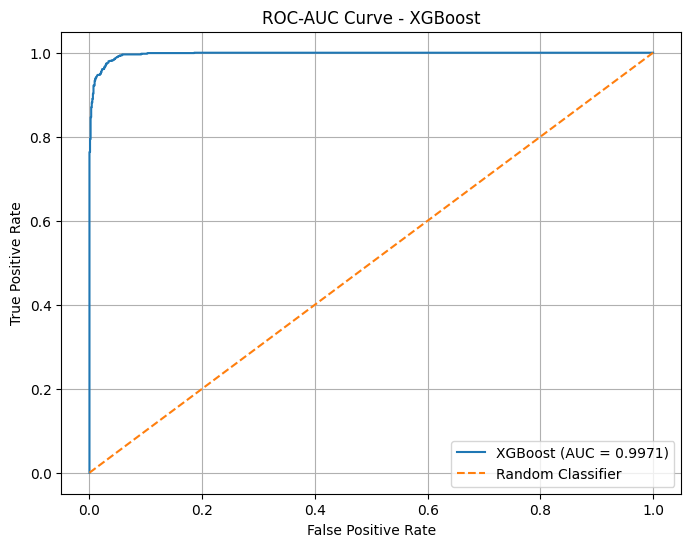

In [110]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores for the positive class (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

# Plot ROC-AUC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC = {auc_score:.4f})'
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - XGBoost')

plt.legend()
plt.grid()
plt.show()

In [111]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of phishing (class 0)
phishing_prob = model.predict_proba(X_test_scaled)[:, 0]

# Convert labels: phishing=1, legitimate=0
y_phishing = (y_test == 0).astype(int)

# Check that both classes exist
print("Classes in test set:", y_phishing.unique())

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_phishing, phishing_prob)

# Youden's J
J = tpr - fpr
best_idx = J.argmax()
best_threshold = thresholds[best_idx]

# AUC
auc_score = roc_auc_score(y_phishing, phishing_prob)

print(f"ROC-AUC: {auc_score:.4f}")
print(f"Selected Threshold: {best_threshold:.4f}")
print(f"TPR / Recall: {tpr[best_idx]:.4f}")
print(f"FPR: {fpr[best_idx]:.4f}")

# Apply threshold
y_pred = (phishing_prob >= best_threshold).astype(int)

print("\nThreshold selected automatically using Youden's J statistic.")

Classes in test set: [1 0]
ROC-AUC: 0.9971
Selected Threshold: 0.4679
TPR / Recall: 0.9663
FPR: 0.0203

Threshold selected automatically using Youden's J statistic.
